<>:153: SyntaxWarning: invalid escape sequence '\d'
<>:170: SyntaxWarning: invalid escape sequence '\d'
<>:153: SyntaxWarning: invalid escape sequence '\d'
<>:170: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_287077/2870665195.py:153: SyntaxWarning: invalid escape sequence '\d'
  ax1.set_xlabel("Features ($1 \dots 12$)", fontsize=11)
/tmp/ipykernel_287077/2870665195.py:170: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_xlabel("Features ($1 \dots 12$)", fontsize=11)


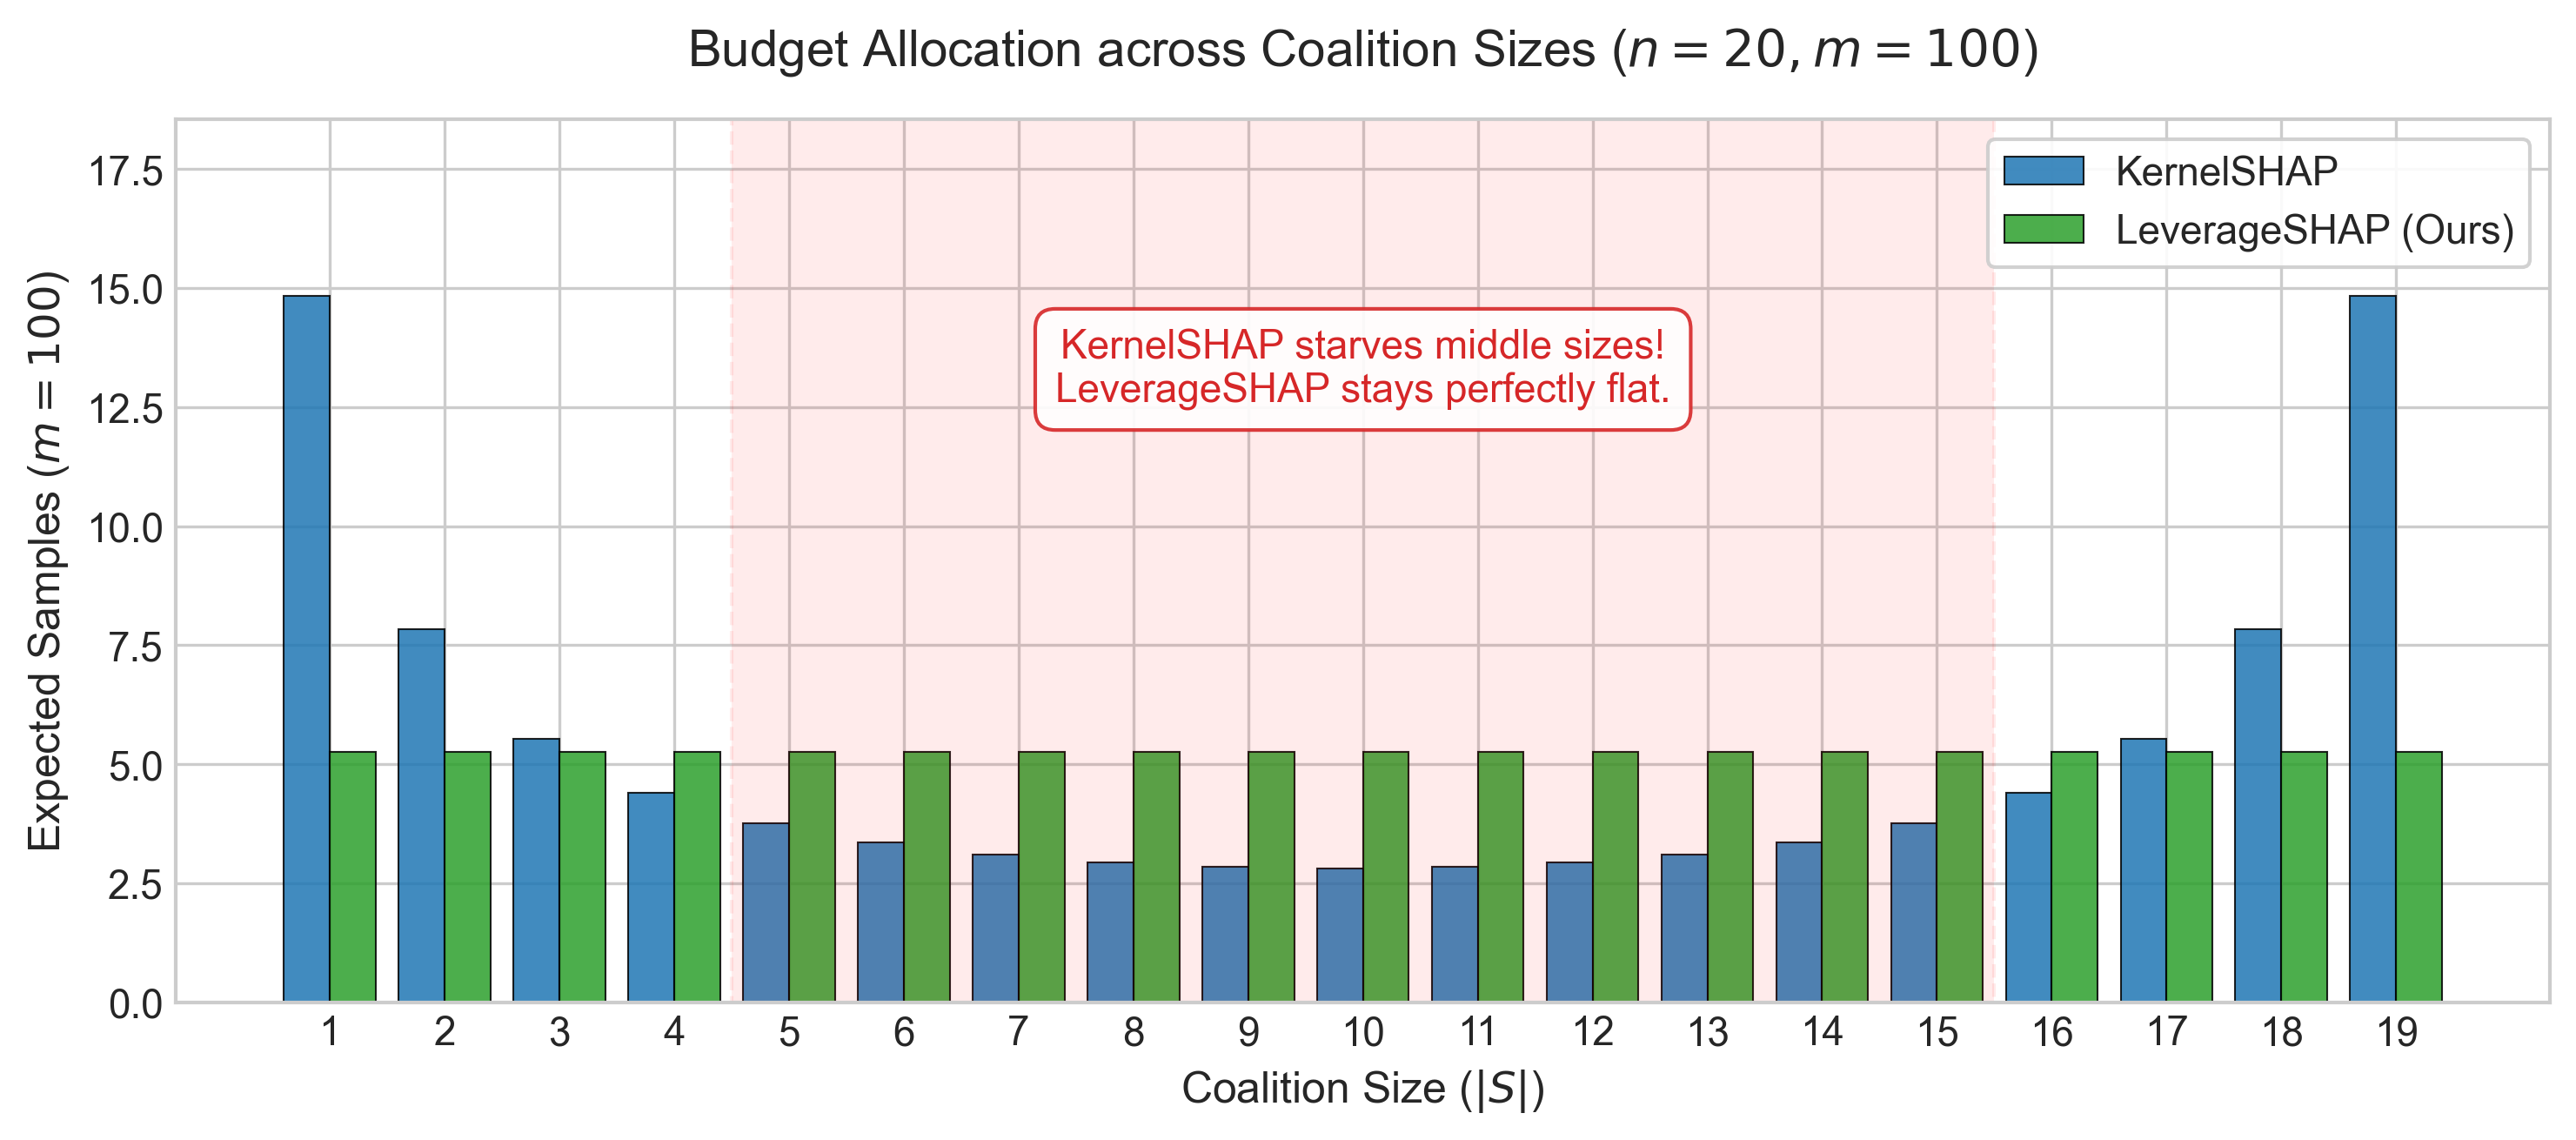

Saved: slide7_idea_a_barchart.png


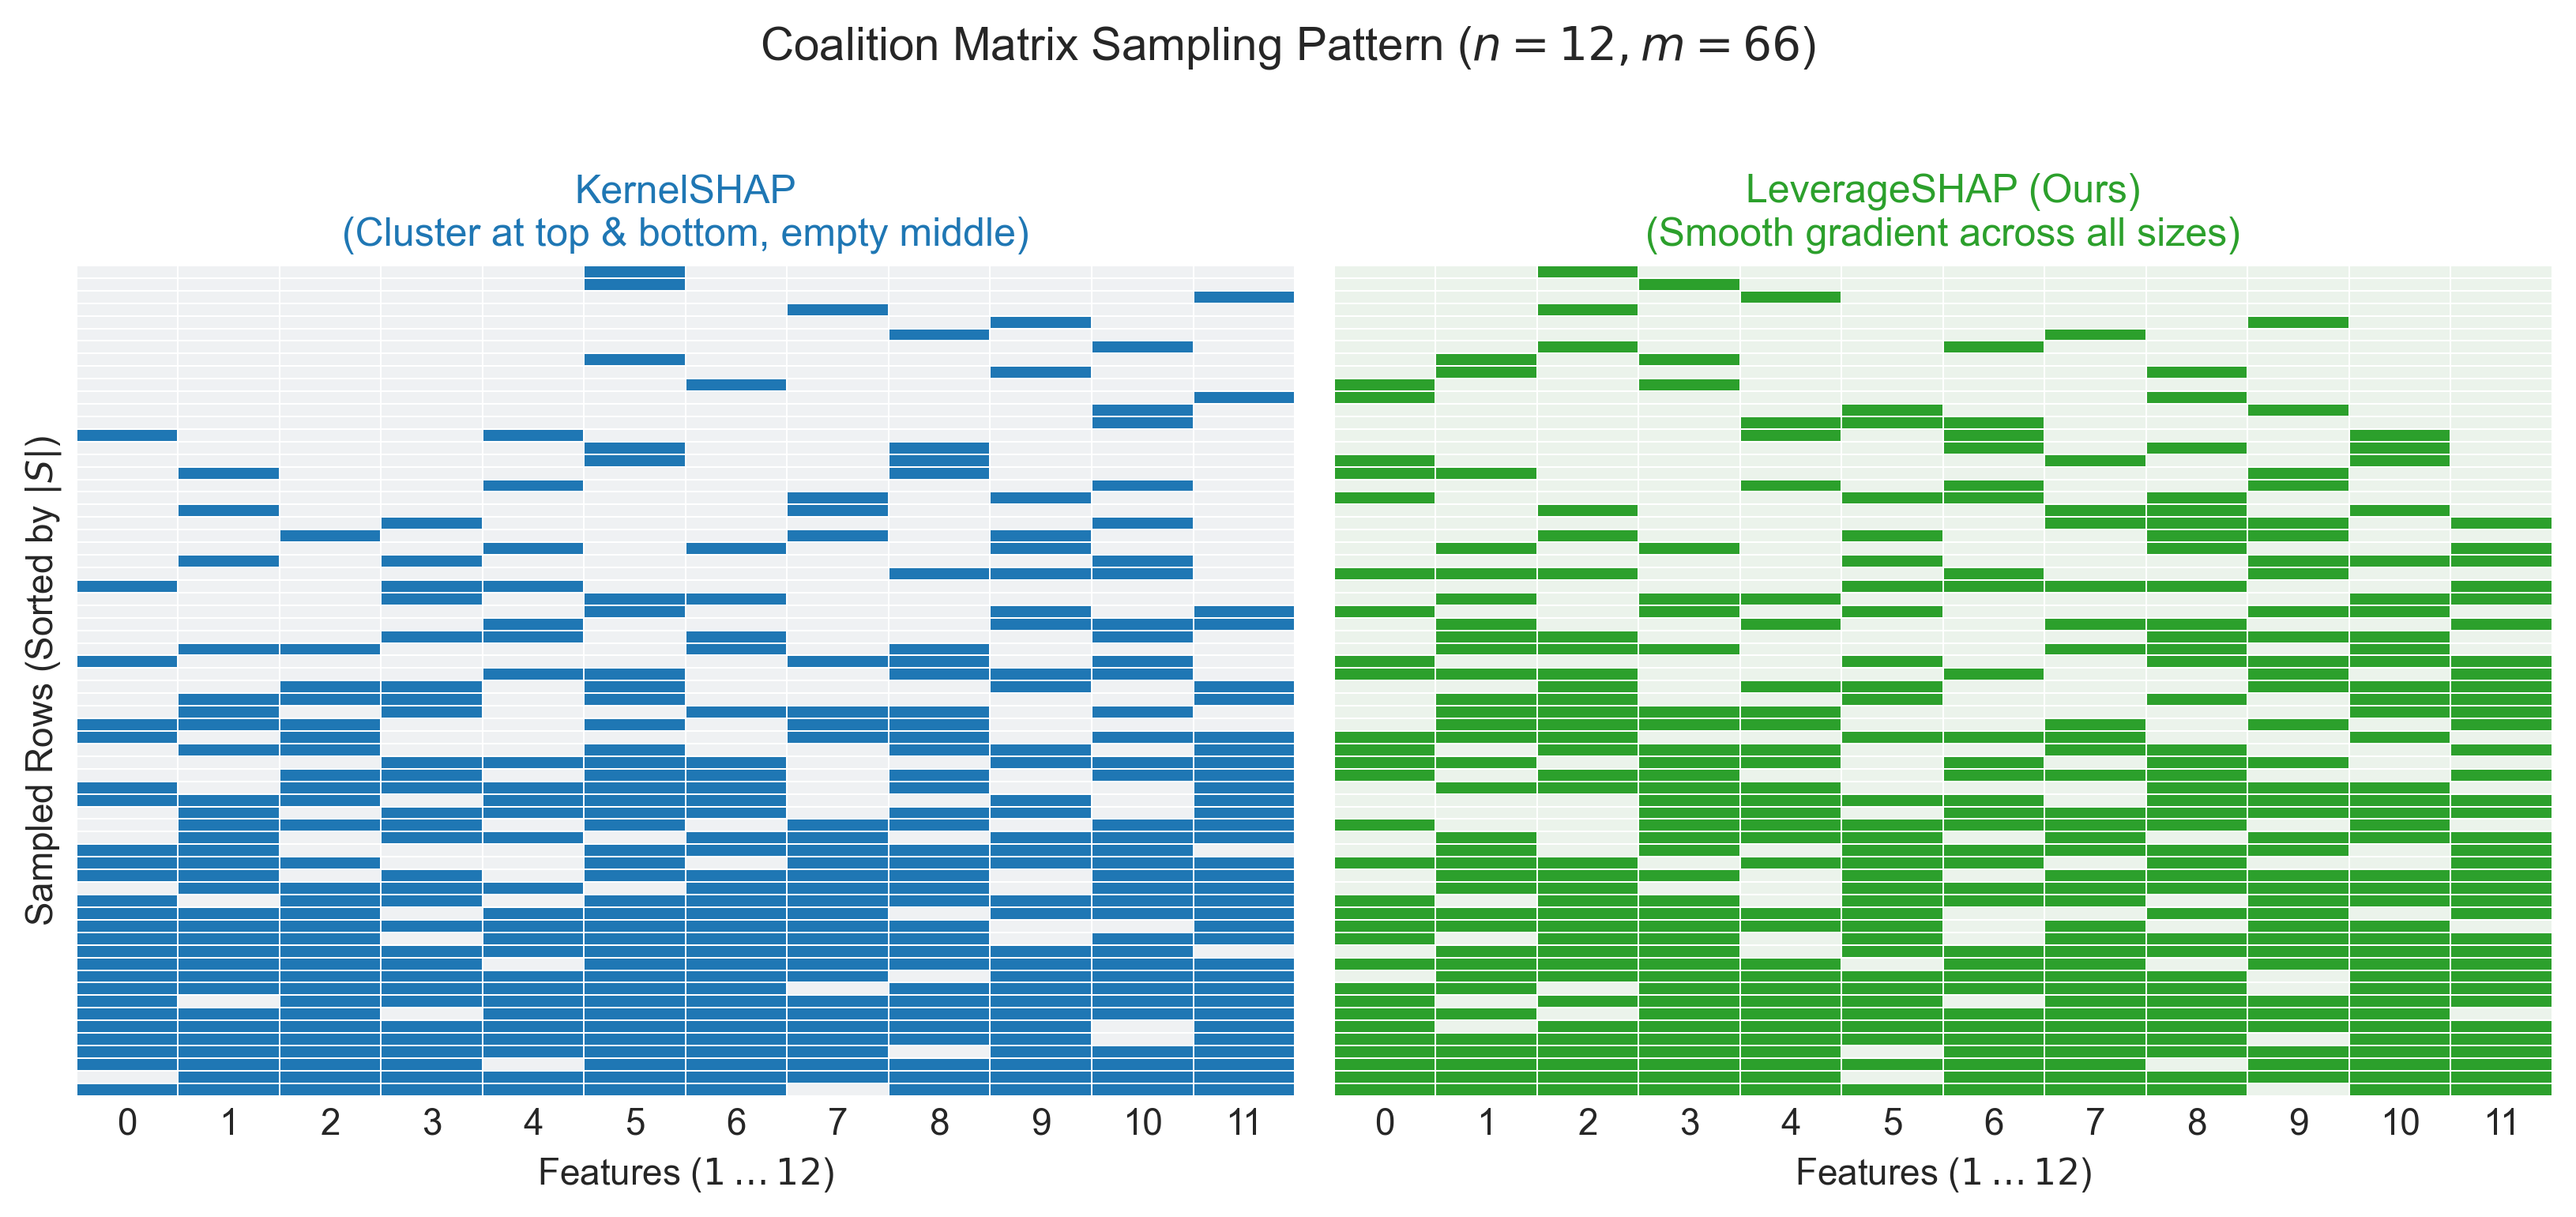

Saved: slide7_idea_b_heatmap.png


In [1]:
# %% [code]
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.special import binom

# Styling-Einstellungen für LMU / Academic Look
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

# Farbschema
COLOR_KS = "#1f77b4"  # KernelSHAP Blau
COLOR_LEV = "#2ca02c"  # LeverageSHAP Grün


# ==============================================================================
# IDEE A: Budget Allocation Bar Chart (Samples pro Koalitionsgröße bei m=100)
# ==============================================================================
def generate_idea_a():
    n = 20  # 20 Features
    m = 100  # Budget = 100 Evaluierungen
    sizes = np.arange(1, n)  # s = 1 .. 19

    # 1. KernelSHAP Gewichte pro Größe s: w(s) ~ 1 / (s * (n - s))
    ks_weights = 1.0 / (sizes * (n - sizes))
    ks_probs = ks_weights / ks_weights.sum()
    ks_samples = ks_probs * m

    # 2. LeverageSHAP Gewichte: Flach über alle n-1 Größen
    lev_probs = np.full(n - 1, 1.0 / (n - 1))
    lev_samples = lev_probs * m

    # Plot erstellen
    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=300)

    x = np.arange(len(sizes))
    width = 0.4

    rects1 = ax.bar(
        x - width / 2,
        ks_samples,
        width,
        label="KernelSHAP",
        color=COLOR_KS,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
    )
    rects2 = ax.bar(
        x + width / 2,
        lev_samples,
        width,
        label="LeverageSHAP (Ours)",
        color=COLOR_LEV,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
    )

    # Beschriftung & Styling
    ax.set_xlabel("Coalition Size ($|S|$)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Expected Samples ($m = 100$)", fontsize=12, fontweight="bold")
    ax.set_title(
        "Budget Allocation across Coalition Sizes ($n=20, m=100$)",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(sizes)
    ax.legend(fontsize=11, frameon=True, facecolor="white", framealpha=0.9)
    ax.set_ylim(0, max(ks_samples) * 1.25)

    # Hervorhebung der "Mitte"
    ax.axvspan(
        3.5, 14.5, color="red", alpha=0.08, linestyle="--", label="Middle sizes starved"
    )
    ax.text(
        9,
        max(ks_samples) * 0.85,
        "KernelSHAP starves middle sizes!\nLeverageSHAP stays perfectly flat.",
        color="#d62728",
        fontsize=11,
        fontweight="bold",
        ha="center",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor="#d62728",
            alpha=0.9,
        ),
    )

    plt.tight_layout()
    plt.savefig("slide7_idea_a_barchart.png", dpi=300)
    plt.show()
    print("Saved: slide7_idea_a_barchart.png")


# ==============================================================================
# IDEE B: Matrix Sampling Heatmap (Gezogene Koalitionen)
# ==============================================================================
def generate_idea_b():
    n = 12  # 12 Features
    m = 66  # Budget = 66 Zeilen
    np.random.seed(42)

    sizes = np.arange(1, n)

    # KernelSHAP Koalitionen sammeln
    ks_weights = 1.0 / (sizes * (n - sizes))
    ks_probs = ks_weights / ks_weights.sum()
    ks_draws = np.random.choice(sizes, size=m, p=ks_probs)
    ks_draws.sort()  # Nach Größe sortieren für schöne Visualisierung

    matrix_ks = np.zeros((m, n), dtype=int)
    for i, s in enumerate(ks_draws):
        cols = np.random.choice(n, size=s, replace=False)
        matrix_ks[i, cols] = 1

    # LeverageSHAP Koalitionen sammeln (exakt gleichmäßige Abdeckung jeder Größe)
    lev_draws = np.repeat(sizes, m // len(sizes))
    lev_draws.sort()

    matrix_lev = np.zeros((m, n), dtype=int)
    for i, s in enumerate(lev_draws):
        cols = np.random.choice(n, size=s, replace=False)
        matrix_lev[i, cols] = 1

    # Plot erstellen (2 Subplots nebeneinander)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=300)

    # Custom Color Maps
    cmap_ks = sns.light_palette(COLOR_KS, as_cmap=True)
    cmap_lev = sns.light_palette(COLOR_LEV, as_cmap=True)

    sns.heatmap(
        matrix_ks,
        ax=ax1,
        cmap=cmap_ks,
        cbar=False,
        linewidths=0.1,
        linecolor="white",
    )
    ax1.set_title(
        "KernelSHAP\n(Cluster at top & bottom, empty middle)",
        fontsize=12,
        fontweight="bold",
        color=COLOR_KS,
    )
    ax1.set_ylabel("Sampled Rows (Sorted by $|S|$)", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Features ($1 \dots 12$)", fontsize=11)
    ax1.set_yticks([])

    sns.heatmap(
        matrix_lev,
        ax=ax2,
        cmap=cmap_lev,
        cbar=False,
        linewidths=0.1,
        linecolor="white",
    )
    ax2.set_title(
        "LeverageSHAP (Ours)\n(Smooth gradient across all sizes)",
        fontsize=12,
        fontweight="bold",
        color=COLOR_LEV,
    )
    ax2.set_xlabel("Features ($1 \dots 12$)", fontsize=11)
    ax2.set_yticks([])

    fig.suptitle(
        "Coalition Matrix Sampling Pattern ($n=12, m=66$)",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig("slide7_idea_b_heatmap.png", dpi=300)
    plt.show()
    print("Saved: slide7_idea_b_heatmap.png")


# Beide Grafiken ausführen
generate_idea_a()
generate_idea_b()